[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatsubaraSoda/Notebook/blob/main/notebooks/%E7%89%A9%E7%90%86%E5%AD%A6/%E7%94%B5%E7%A3%81%E5%AD%A6/%E5%85%89%E5%AD%A6/focal-points-and-planes.ipynb)

# 焦点与焦平面

Hetch 光学教材第五章几何光学，Focal Points and Planes 节。尝试给薄透镜进行简单地建模，并分析焦点与焦平面的性质。

## 符号约定

| 物理量 | 符号 |
| :--: | :--: |
| 左焦点 | $F_1$ |
| 右焦点 | $F_2$ |
| 焦距 | $f$ |
| 光线交点 | $P$ |
| 物点 | $O$ |
| 像点 | $I$ |
| 物距 | $s_o$ |
| 像距 | $s_i$ |
| 入射方向角 | $\theta_1$ |
| 折射方向角 | $\theta_2$ |
| 入射斜率 | $u$ |
| 折射斜率 | $v$ |


## 薄透镜建模

如何使用 Python 模拟光线在薄透镜的折射行为。需要注意的是，本文的全部讨论，均在**近轴近似假设**的基础上进行。在这种情况下，有：

$$
\begin{aligned}
\sin\theta &\approx \theta \\
\cos\theta &\approx 1 \\
\tan\theta &\approx \theta
\end{aligned}
$$

考虑一束光线，从 $xy$ 平面的左侧，射向右侧。中途与薄透镜（位于 $x=0$ 处，其焦距为 $f$）相交于点 $P(0, p_y)$。薄透镜的光学中心坐标为 $(0,0)$，光轴为 $x$ 轴。

已知入射方向角为 $\theta_1$，求折射方向角 $\theta_2$ 是多少？（方向角指与 $x$ 正半轴的夹角）。在近轴近似下，我们令入射斜率为 $u \approx \tan\theta_1$，折射光线斜率为 $v \approx \tan\theta_2$，这有益于简化推导过程。

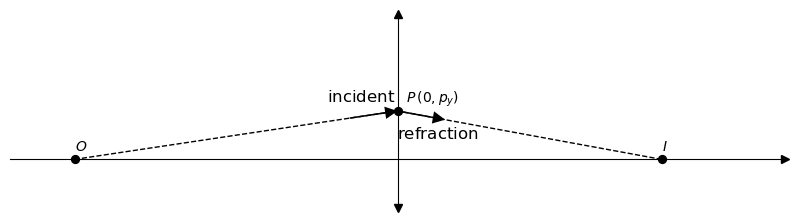

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field

# 已知
@dataclass
class Knowns:
    P: list = field(default_factory=lambda: [0.0, 1.0])
    f: float = 3.0
    u: float = 0.15

    @property
    def v(self) -> float:
        """折射斜率：v = u - p_y / f"""
        return self.u - self.P[1] / self.f

knowns = Knowns()

def set_scene(ax):
    # 教科书式坐标轴
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 上下左右的范围
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-8,8])
    ax.set_ylim([-1, 3])

    # x 轴右箭头（代表光轴）
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    # y 轴上箭头（薄透镜高度无限延长）
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
    # y 轴下箭头（薄透镜高度无限延长）
    ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False)

# 绘制交点
def draw_P(ax, knowns):
    x, y = knowns.P
    ax.scatter(x, y, s=32, zorder=5, color='k')
    ax.annotate(r'$P\,(0, p_y)$', (x, y), xytext=(6, 6), textcoords='offset points')

# 已知斜率求单位方向向量
def unit_direction_from_slope(u: float) -> np.ndarray:
    d = np.array([1.0, u])
    return d / np.linalg.norm(d)

# 绘制入射光单位向量
def draw_incident(ax, knowns):
    P = np.asarray(knowns.P, dtype=float)
    d_hat = unit_direction_from_slope(knowns.u)
    start = P - d_hat
    vec = P - start
    offset_mid = np.array([-0.25, 0.2])
    mid = start + 0.5 * vec + offset_mid
    ax.quiver(
        start[0], start[1], vec[0], vec[1],
        angles='xy', scale_units='xy', scale=1, 
        color='k', width=0.002, 
        headwidth=8, headlength=8, headaxislength=8,
        zorder=6
    )
    ax.text(mid[0], mid[1], r'$\text{incident}$', fontsize=12,
            ha='center', va='bottom', color='k')

# 绘制折射光单位向量
def draw_refraction(ax, knowns):
    P = np.asarray(knowns.P, dtype=float)
    d_hat = unit_direction_from_slope(knowns.v)
    start = P
    end = P + d_hat
    vec = end - start
    offset_mid = np.array([0.35, -0.55])
    mid = start + 0.5 * vec + offset_mid
    ax.quiver(
        start[0], start[1], vec[0], vec[1],
        angles='xy', scale_units='xy', scale=1,
        color='k', width=0.002,
        headwidth=8, headlength=8, headaxislength=8,
        zorder=6
    )
    ax.text(mid[0], mid[1], r'$\text{refraction}$', fontsize=12,
            ha='center', va='bottom', color='k')

# 入射光反向延长线与 x 轴交点 → 物点 O
def object_point(knowns) -> np.ndarray:
    P = np.asarray(knowns.P, dtype=float)
    do = -P[1] / knowns.u
    return np.array([do, 0.0])

# 折射光延长线与 x 轴交点 → 像点 I
def image_point(knowns) -> np.ndarray:
    P = np.asarray(knowns.P, dtype=float)
    di = -P[1] / knowns.v
    return np.array([di, 0.0])

# 绘制入射光反向，与 x 轴交于物点
def draw_object(ax, knowns):
    P = np.asarray(knowns.P, dtype=float)
    O = object_point(knowns)

    ax.plot([O[0], P[0]], [O[1], P[1]], 'k--', lw=1)
    ax.scatter(O[0], O[1], s=32, color='k', zorder=5)
    ax.annotate('$O$', O, xytext=(0, 6), textcoords='offset points')

# 绘制折射光延长，与 x 轴交于像点
def draw_image(ax, knowns):
    P = np.asarray(knowns.P, dtype=float)
    I = image_point(knowns)

    ax.plot([I[0], P[0]], [I[1], P[1]], 'k--', lw=1)
    ax.scatter(I[0], I[1], s=32, color='k', zorder=5)
    ax.annotate('$I$', I, xytext=(0, 6), textcoords='offset points')

fig, ax = plt.subplots(figsize=(10, 6))
set_scene(ax)
draw_P(ax, knowns)
draw_incident(ax, knowns)
draw_refraction(ax, knowns)
draw_object(ax, knowns)
draw_image(ax, knowns)

当入射光打在薄透镜点 $P$ 时，我们可以认为这束光是从光轴上某一物点发射出来的。如图所示，incident 代表入射光的方向单位向量。我们沿着反方向延长，与 $x$ 轴交于点 $O$，即物点。

当入射光线斜率 $u$ 已知时，我们可以得到入射光线所在直线的方程：

$$
y = p_y + u x
$$

令 $y=0$，解得： 

$$\displaystyle x = -\frac{p_y}{u}$$

因此，物点的坐标为 $O(-\frac{p_y}{u}, 0)$ 。物点可能在薄透镜左侧（实像），也可能在右侧（虚像）。为了应用高斯透镜公式，我们需要找出 $s_o$ 与 $-\frac{p_y}{u}$ 之间的符号关系。一共有四种情况，可以通过以下真值表确定：

| $p_y$ | $u$ | $\displaystyle -\frac{p_y}{u}$ | $s_o$ |
| :--: | :--: | :--: | :--: |
| $>0$ | $>0$ | $<0$ | $>0$ |
| $>0$ | $<0$ | $>0$ | $<0$ |
| $<0$ | $>0$ | $>0$ | $<0$ |
| $<0$ | $<0$ | $<0$ | $>0$ |

通过对 $p_y$ 和 $u$ 的正负符号进行排列组合，可以确定 $s_o = \frac{p_y}{u}$。应用高斯透镜公式可得：

$$
\frac{u}{p_y} + \frac{1}{s_i} = \frac{1}{f}
$$

当折射光从点 $P$ 射出时，假设其所处直线的斜率为 $v$，那么该直线的方程为：

$$
y = p_y + v x
$$

令 $y=0$，解得： 

$$\displaystyle x = -\frac{p_y}{v}$$

于是像点坐标为 $I(-\frac{p_y}{v}, 0)$。通过真值表分析 $s_i$ 与 $-\frac{p_y}{v}$ 之间的符号关系：

| $p_y$ | $v$ | $\displaystyle -\frac{p_y}{u}$ | $s_i$ |
| :--: | :--: | :--: | :--: |
| $>0$ | $>0$ | $<0$ | $<0$ |
| $>0$ | $<0$ | $>0$ | $>0$ |
| $<0$ | $>0$ | $>0$ | $>0$ |
| $<0$ | $<0$ | $<0$ | $<0$ |

所以有 $s_i = -\frac{p_y}{u}$。再次应用高斯透镜公式，有：

$$
\frac{u}{p_y} - \frac{v}{p_y} = \frac{1}{f}
$$

简化得：

$$
\boxed{
v = u - \frac{p_y}{f}
}
$$

于是我们得到了 $v$ 关于 $u$ 的表达式，意味着当知道 $u$ 的值时，可以通过上式得到 $v$ 的值。我们将在 `python` 中使用该方程模拟薄透镜（仅限坐落于 $x=0$ 处的）。

## 焦点

固定物点位置，从其向薄透镜发射若干条光线，观察折射后的会聚或发散行为；对每种物距各绘一幅光路图。

拟定绘制七副图，分别对应 $s_o = \infty,\, 3f,\, 2f,\, 1.5f,\, f,\, 0.75f,\, 0.5f$。每次从实物处发射七束光线。

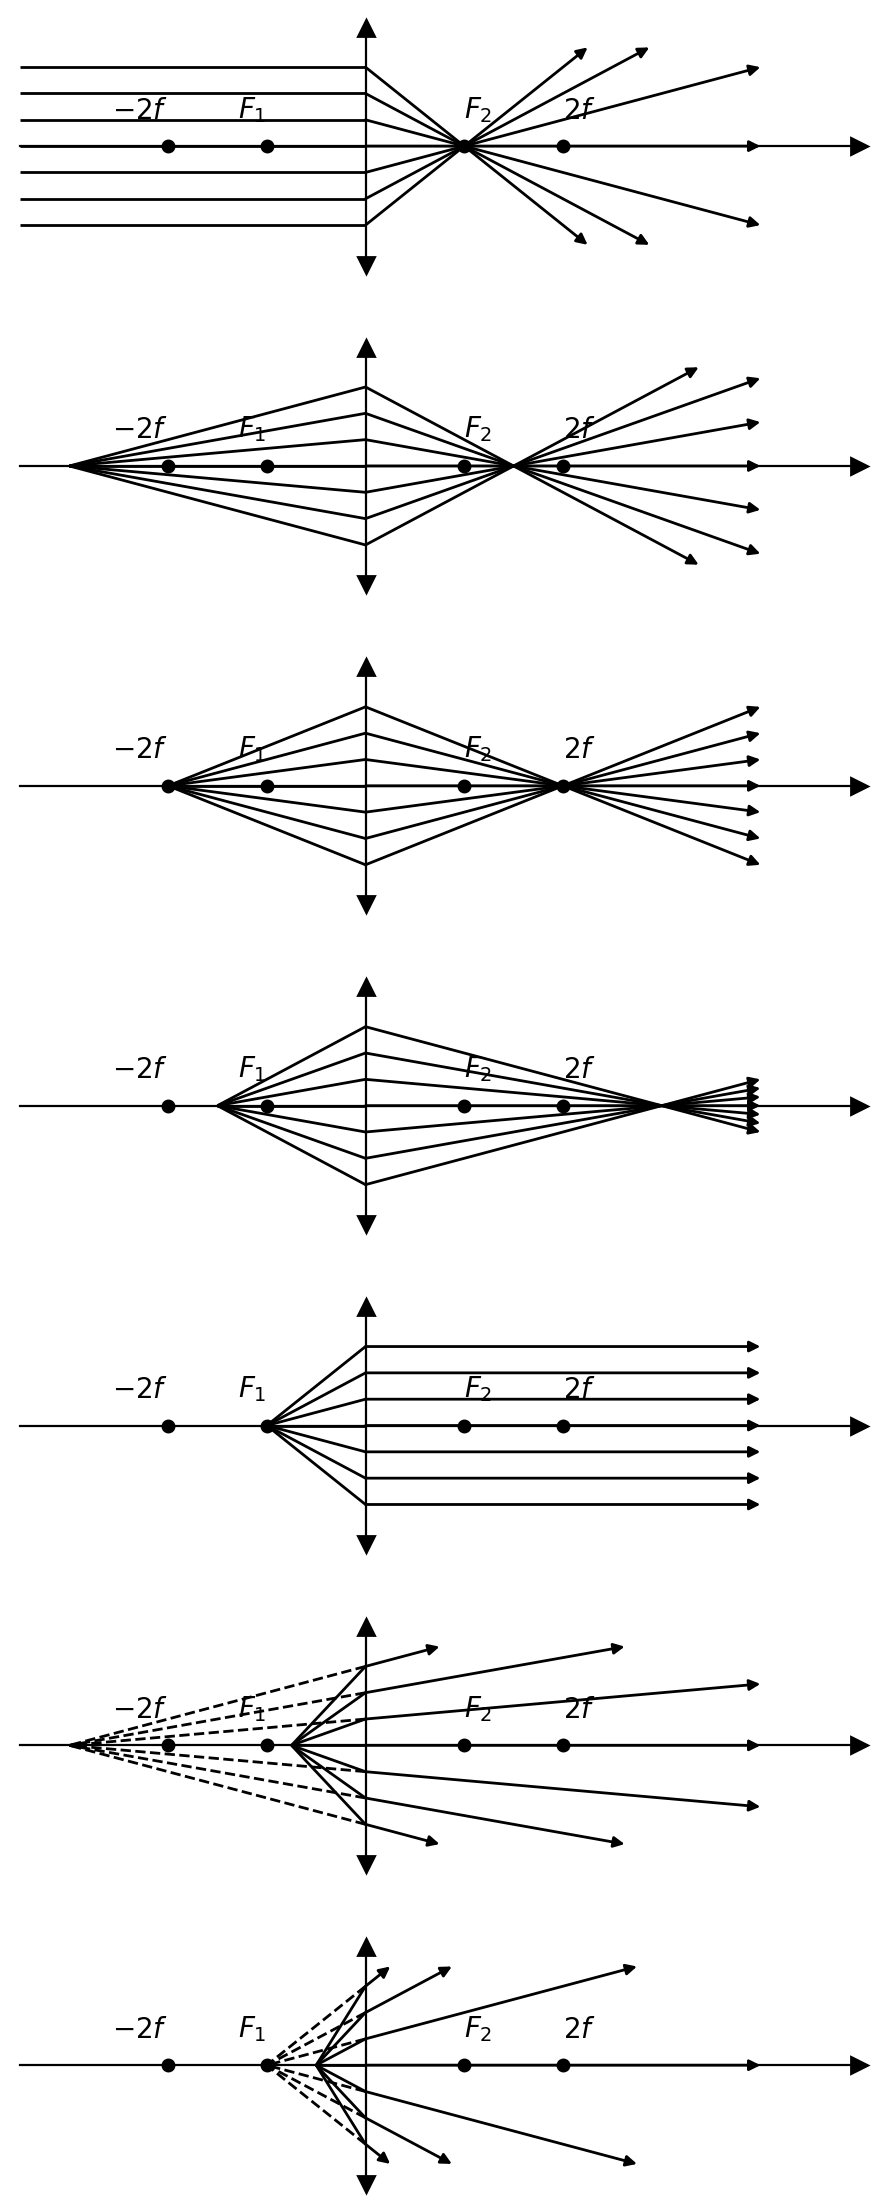

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

from dataclasses import dataclass, field

@dataclass
class Knowns_FocalPoints:
    P: np.ndarray = field(default_factory=lambda: np.linspace(-0.8, 0.8, 7))
    f: float = 1.0

    @property
    def s_o(self) -> np.ndarray:
        return np.array([np.inf, 3, 2, 1.5, 1, 0.75, 0.5]) * self.f

def set_scene(ax):
    # 教科书式坐标轴
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 上下左右的范围
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-3.5,5])
    ax.set_ylim([-1.2, 1.2])

    # x 轴右箭头（代表光轴）
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    # y 轴上箭头（薄透镜高度无限延长）
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
    # y 轴下箭头（薄透镜高度无限延长）
    ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False)

# 光轴上的 -2f, -f, f, 2f
FOCAL_AXIS_RATIOS = (-2, -1, 1, 2)
FOCAL_AXIS_LABELS = {
    -2: r"$-2f$",
    -1: r"$F_1$",
    1: r"$F_2$",
    2: r"$2f$",
}

def draw_focal_axis_marks(ax, f: float):
    for k in FOCAL_AXIS_RATIOS:
        x = k * f
        ax.scatter(x, 0, s=16, color="k", zorder=5)
        ha = "right" if k < 0 else "left"
        ax.annotate(
            FOCAL_AXIS_LABELS[k],
            (x, 0),
            xytext=(0, 8),
            textcoords="offset points",
            ha=ha,
            va="bottom",
        )

@dataclass
class RaySlopes:
    u: np.ndarray
    v: np.ndarray

def slopes_from_object(s_o: float, f: float, P: np.ndarray) -> RaySlopes:
    """物点 O(-s_o, 0) 经各透镜交点高度 P 的入射斜率 u 与折射斜率 v。"""
    u = P / s_o
    v = u - P / f
    return RaySlopes(u=u, v=v)

Y_OUT_CLIP = 1.0

def lens_points(p_y: np.ndarray) -> np.ndarray:
    """透镜交点坐标 P_i = (0, p_y)，形状 (n, 2)。"""
    return np.column_stack([np.zeros_like(p_y), p_y])

def image_distance(s_o: float, f: float) -> float:
    """高斯透镜公式：1/s_o + 1/s_i = 1/f；s_o = f 时 s_i → ∞。"""
    denominator = 1.0 / f - 1.0 / s_o
    if np.isclose(denominator, 0.0):
        return np.inf
    return 1.0 / denominator

def axis_hit_x(P_i: np.ndarray, v: float) -> float:
    """折射线过 P_i、斜率 v，与光轴 y=0 的交点横坐标。"""
    return -P_i[1] / v

def draw_refracted_backward_to_axis(ax, P_i: np.ndarray, v: float) -> None:
    """沿折射线反向延长（虚线）至光轴；不标像点。"""
    if v == 0:
        return
    I = np.array([axis_hit_x(P_i, v), 0.0])
    ax.plot(
        [P_i[0], I[0]], [P_i[1], I[1]],
        "k--", lw=1.0, zorder=3,
    )

def outgoing_vector(P_i: np.ndarray, v: float, d: float) -> np.ndarray:
    """出射段 (dx, dy)：默认水平延伸 d；若终点 y 超出 ±Y_OUT_CLIP 则截到边界。"""
    p_y = P_i[1]
    end_y = p_y + v * d
    if -Y_OUT_CLIP <= end_y <= Y_OUT_CLIP:
        return np.array([d, v * d])
    target_y = Y_OUT_CLIP if end_y > Y_OUT_CLIP else -Y_OUT_CLIP
    if v == 0:
        return np.array([d, 0.0])
    dx = (target_y - p_y) / v
    return np.array([dx, target_y - p_y])

def draw_rays_from_infinity(
    ax,
    f: float,
    P: np.ndarray,
    d: float,
) -> RaySlopes:
    """s_o → ∞：入射为平行光，u=0；自各 P(0, p_y) 向左画水平线至 xlim 左缘；再画出射。"""
    x_left = ax.get_xlim()[0]
    u = np.zeros_like(P, dtype=float)
    v = u - P / f
    s_i = f

    for P_i, v_i in zip(lens_points(P), v):
        P_i = np.asarray(P_i, dtype=float)
        start = np.array([x_left, P_i[1]])
        ax.plot(
            [start[0], P_i[0]], [start[1], P_i[1]],
            "k-", lw=1.0, solid_capstyle="butt", zorder=4,
        )
        end = P_i + outgoing_vector(P_i, v_i, d)
        ax.add_patch(FancyArrowPatch(
            P_i, end,
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=1.0,
            color="k",
            shrinkA=0, shrinkB=0,
            zorder=6,
        ))
        if s_i < 0:
            draw_refracted_backward_to_axis(ax, P_i, v_i)

    return RaySlopes(u=u, v=v)

def draw_rays_from_object(
    ax,
    s_o: float,
    f: float,
    P: np.ndarray,
    d: float,
) -> RaySlopes:
    """O(-s_o, 0) → P(0, p_y) 画入射段；P 起水平延伸 d 画出射箭头。不标 O、I。"""
    O = np.array([-s_o, 0.0])
    slopes = slopes_from_object(s_o, f, P)
    s_i = image_distance(s_o, f)

    for P_i, v_i in zip(lens_points(P), slopes.v):
        P_i = np.asarray(P_i, dtype=float)
        end = P_i + outgoing_vector(P_i, v_i, d)
        ax.plot(
            [O[0], P_i[0]], [O[1], P_i[1]],
            "k-", lw=1.0, solid_capstyle="butt", zorder=4,
        )
        ax.add_patch(FancyArrowPatch(
            P_i, end,
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=1.0,
            color="k",
            shrinkA=0, shrinkB=0,
            zorder=6,
        ))
        if s_i < 0:
            draw_refracted_backward_to_axis(ax, P_i, v_i)

    return slopes

knowns = Knowns_FocalPoints()
RAY_EXTENT_D = 4.0

fig, axes = plt.subplots(7, 1, figsize=(10, 14), dpi=200)
for i, (ax, s_o_i) in enumerate(zip(axes, knowns.s_o)):
    set_scene(ax)
    draw_focal_axis_marks(ax, knowns.f)
    if i == 0:
        draw_rays_from_infinity(ax, knowns.f, knowns.P, RAY_EXTENT_D)
    else:
        draw_rays_from_object(ax, s_o_i, knowns.f, knowns.P, RAY_EXTENT_D)

fig.subplots_adjust(hspace=0.35)

## 焦平面

在近轴近似下，焦平面是垂直于主光轴的成像平面。

- 平行于光轴的一束入射光，在透过薄凸透镜后，会汇聚于右侧的像方焦点。
- 与光轴有夹角的一束平行入射光，透过透镜后同样会汇聚于一点。这个会聚点，正是那条穿过光心的光线与焦平面的交点。

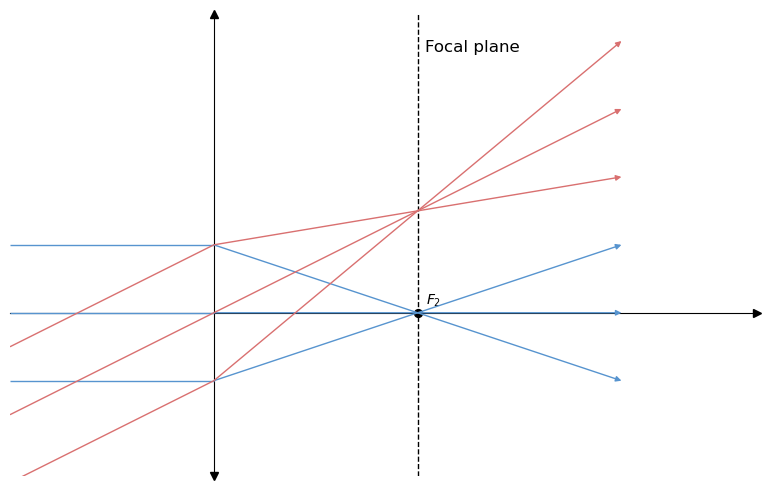

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

from dataclasses import dataclass

@dataclass
class Config:
    focal_length: float = 1.5

def set_scene(ax):
    # 教科书式坐标轴
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 上下左右的范围
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-1.5, 4.0])
    ax.set_ylim([-1.2, 2.2])

    # x 轴右箭头（代表光轴）
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    # y 轴上箭头（薄透镜高度无限延长）
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
    # y 轴下箭头（薄透镜高度无限延长）
    ax.plot(0, 0, "vk", transform=ax.get_xaxis_transform(), clip_on=False)

def draw_image_side_focus(ax, config: Config) -> None:
    """像方焦点 F_2：光轴上 x = focal_length 处。"""
    x = config.focal_length
    ax.scatter(x, 0, s=32, color="k", zorder=5)
    ax.annotate(r"$F_2$", (x, 0), xytext=(6, 6), textcoords="offset points")

def draw_focal_plane(ax, config: Config) -> None:
    """像方焦平面：过 F_2、垂直于光轴的直线（2D 中为竖直虚线）。"""
    x_f2 = config.focal_length
    y_f2 = 0.0
    y0, y1 = ax.get_ylim()
    ax.plot([x_f2, x_f2], [y0, y1], "k--", lw=1.0, zorder=3)
    ax.text(x_f2 + 0.4, y_f2 + 1.9, "Focal plane", ha="center", va="bottom", fontsize=12, color="k")

def draw_parallel_rays(ax, m: float, b: float, f: float, color: str = "k") -> None:
    """三条平行入射光：y = m x + c，c ∈ {-b, 0, b}；c=0 过光学中心 (0,0)。

    入射斜率 u = m，透镜处高度 p_y = c；折射斜率 v = u - p_y / f。
    入射段：xlim 左端至 0；出射段：x = 0 至 2.0 f。
    """
    x_left = ax.get_xlim()[0]
    x_end = 2.0 * f
    xs = np.array([x_left, 0.0])
    for c in (-b, 0.0, b):
        p_y = c
        u = m
        v = u - p_y / f
        ys = m * xs + c
        ax.plot(xs, ys, "-", color=color, lw=1.0, solid_capstyle="butt", zorder=4)
        P_i = np.array([0.0, p_y])
        end = np.array([x_end, p_y + v * x_end])
        ax.add_patch(FancyArrowPatch(
            P_i, end,
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=1.0,
            color=color,
            shrinkA=0, shrinkB=0,
            zorder=6,
        ))

def draw_axial_parallel_rays(ax, b: float, f: float, color: str = "#5794CF") -> None:
    """轴向平行光：m = 0，即 y = ±b 与 y = 0。"""
    draw_parallel_rays(ax, m=0.0, b=b, f=f, color=color)

def draw_oblique_parallel_rays(ax, m: float, b: float, f: float, color: str = "#D97070") -> None:
    """斜向平行光：y = m x + c。"""
    draw_parallel_rays(ax, m=m, b=b, f=f, color=color)

config = Config()

fig, ax = plt.subplots(figsize=(10, 6))
set_scene(ax)
draw_image_side_focus(ax, config)
draw_focal_plane(ax, config)
draw_axial_parallel_rays(ax, b=0.5, f=config.focal_length)
draw_oblique_parallel_rays(ax, m=0.5, b=0.5, f=config.focal_length)

## 其它

**原文摘录**（Hecht, *Optics*, 5th ed., “Focal Points and Planes”）

> As a rule-of-thumb when sketching ray diagrams, draw the lens diameter (the vertical extent) roughly the size of the focal length.